In [1]:
# 启用交互式后端
%matplotlib widget

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import (
    Slider, Button, CheckButtons, RadioButtons,
    TextBox
)

# 设置中文字体支持（可选）
plt.rcParams.update({
    "font.sans-serif": ["PingFang SC"],
    "axes.unicode_minus": False,
    "figure.dpi": 100
})

def reset():
    plt.close("all")

# Matplotlib 交互式组件

Matplotlib 自带一套基于 `matplotlib.widgets` 的交互式组件，
可以直接在图表中添加滑块、按钮、复选框等控件，让图表"活"起来。

**本节课目标**：掌握 Matplotlib 交互组件的使用模式——
学会将滑块、按钮、复选框、文本框、区间选择器等嵌入图表，并绑定回调函数。

---

## 1. Slider — 滑块

**Slider** 是最常用的交互组件，适合让用户通过拖动来调整连续数值。

基本用法：创建 Slider 对象，绑定 `on_changed` 回调。

0

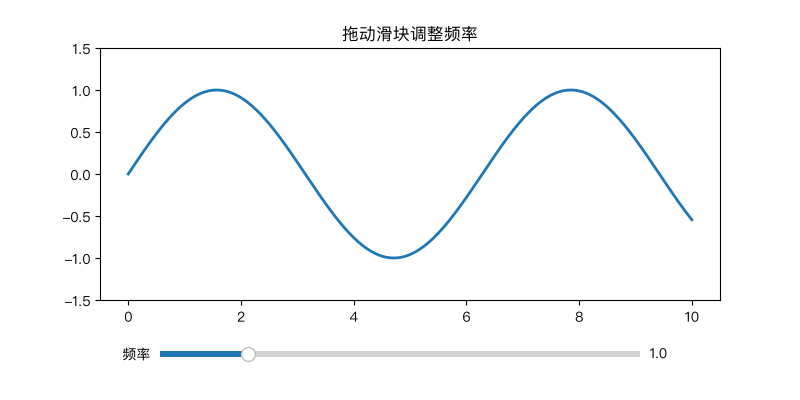

In [5]:
reset()
fig, ax = plt.subplots(figsize=(8, 4))
fig.subplots_adjust(bottom=0.25)

x = np.linspace(0, 10, 500)
line, = ax.plot(x, np.sin(x), lw=2)
ax.set_ylim(-1.5, 1.5)
ax.set_title('拖动滑块调整频率')

# 创建滑块 Axes 和 Slider 控件
slider_ax = fig.add_axes((0.2, 0.1, 0.6, 0.03))
slider = Slider(
    ax=slider_ax, label='频率', valmin=0.1, valmax=5.0,
    valinit=1.0, valstep=0.1
)

def update(freq):
    line.set_ydata(np.sin(freq * x))
    fig.canvas.draw_idle()

slider.on_changed(update)

多个滑块分别控制不同参数，实现多维度调整。

0

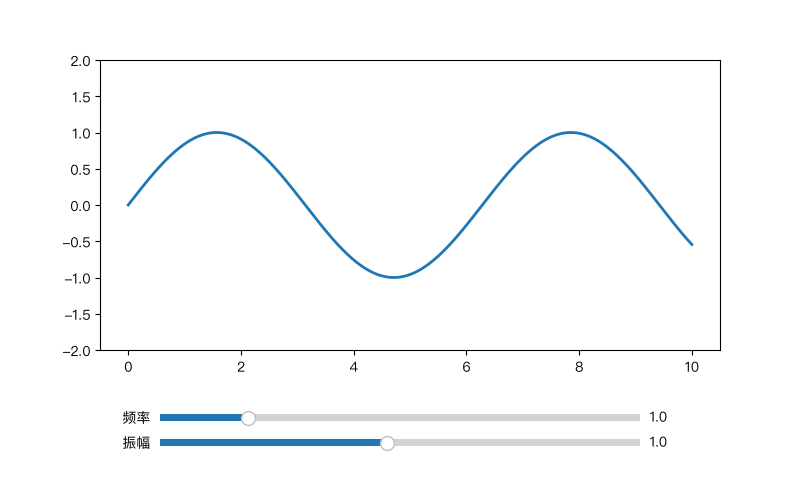

In [6]:
reset()
fig, ax = plt.subplots(figsize=(8, 5))
fig.subplots_adjust(bottom=0.3)

x = np.linspace(0, 10, 500)
line, = ax.plot(x, np.sin(x), lw=2)
ax.set_ylim(-2, 2)

# 频率滑块
freq_slider_ax = fig.add_axes((0.2, 0.15, 0.6, 0.03))
freq_slider = Slider(freq_slider_ax, '频率', 0.1, 5.0, valinit=1.0)

# 振幅滑块
amp_slider_ax = fig.add_axes((0.2, 0.1, 0.6, 0.03))
amp_slider = Slider(amp_slider_ax, '振幅', 0.1, 2.0, valinit=1.0)

def update(_):
    line.set_ydata(amp_slider.val * np.sin(freq_slider.val * x))
    fig.canvas.draw_idle()

freq_slider.on_changed(update)
amp_slider.on_changed(update)

---

## 2. Button — 按钮


0

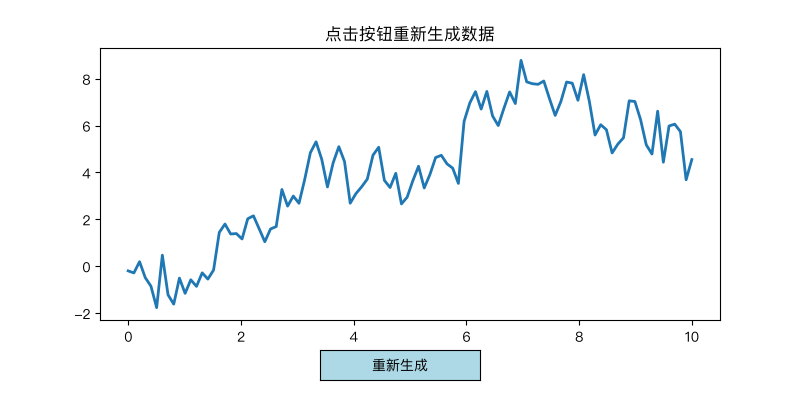

In [10]:
reset()
fig, ax = plt.subplots(figsize=(8, 4))
fig.subplots_adjust(bottom=0.2)

x = np.linspace(0, 10, 100)
line, = ax.plot(x, np.random.randn(100).cumsum(), lw=2)
ax.set_title('点击按钮重新生成数据')

button_ax = fig.add_axes((0.4, 0.05, 0.2, 0.075))
button = Button(button_ax, '重新生成', color='lightblue', hovercolor='skyblue')

def regenerate(event):
    line.set_ydata(np.random.randn(100).cumsum())
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()

button.on_clicked(regenerate)

---

## 3. CheckButtons — 复选框

**CheckButtons** 允许用户切换多个独立开关，常用于控制多条曲线的显隐。

0

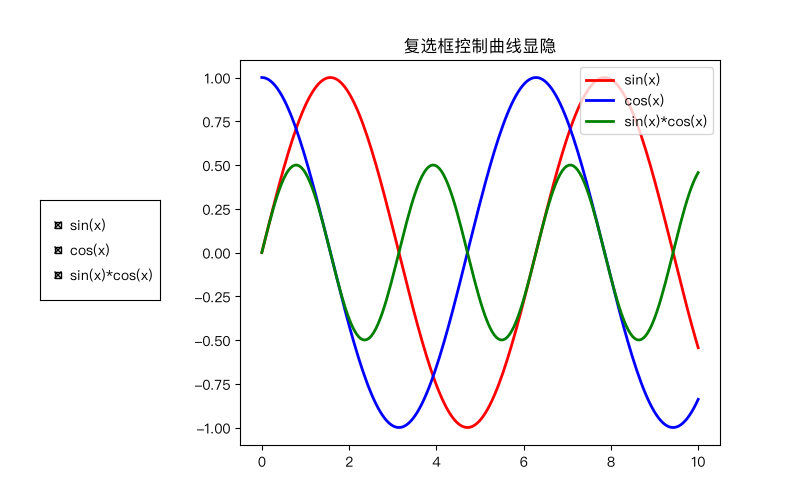

In [12]:
reset()
fig, ax = plt.subplots(figsize=(8, 5))
fig.subplots_adjust(left=0.3)

x = np.linspace(0, 10, 200)
lines = {}
colors = ['red', 'blue', 'green']
labels = ['sin(x)', 'cos(x)', 'sin(x)*cos(x)']
funcs = [np.sin, np.cos, lambda x: np.sin(x) * np.cos(x)]

for label, color, func in zip(labels, colors, funcs):
    line, = ax.plot(x, func(x), color=color, lw=2, label=label, visible=True)
    lines[label] = line

ax.legend(loc='upper right')
ax.set_title('复选框控制曲线显隐')

check_ax = fig.add_axes((0.05, 0.4, 0.15, 0.2))
check = CheckButtons(check_ax, labels, [True, True, True])

def toggle(label):
    lines[label].set_visible(not lines[label].get_visible())
    fig.canvas.draw_idle()

check.on_clicked(toggle)

---

## 4. RadioButtons — 单选按钮

**RadioButtons** 用于从一组互斥选项中选择一个，适合切换图表类型或数据源。

0

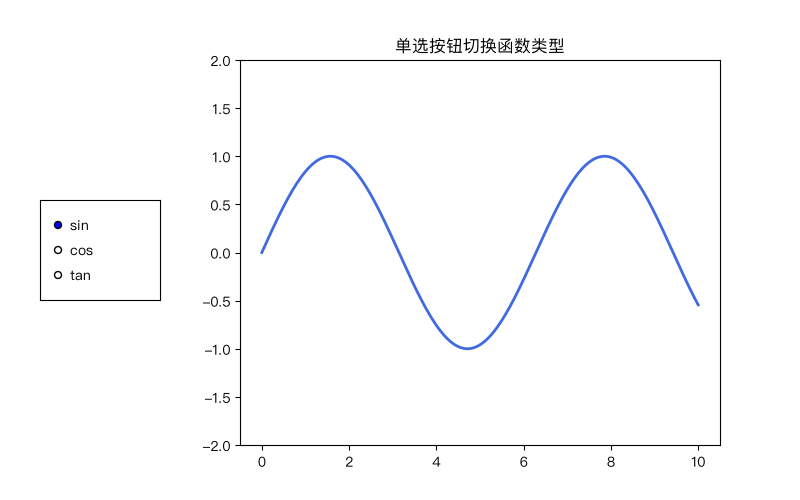

In [13]:
reset()
fig, ax = plt.subplots(figsize=(8, 5))
fig.subplots_adjust(left=0.3)

x = np.linspace(0, 10, 200)
line, = ax.plot(x, np.sin(x), lw=2, color='royalblue')
ax.set_ylim(-2, 2)
ax.set_title('单选按钮切换函数类型')

radio_ax = fig.add_axes((0.05, 0.4, 0.15, 0.2))
radio = RadioButtons(radio_ax, ('sin', 'cos', 'tan'))

func_map = {
    'sin': np.sin,
    'cos': np.cos,
    'tan': lambda x: np.tan(x) * 0.5  # 缩放便于显示
}

def switch(label):
    line.set_ydata(func_map[label](x))
    fig.canvas.draw_idle()

radio.on_clicked(switch)

---

## 5. TextBox — 文本框

**TextBox** 获取用户输入的文本，适合需要精确数值或自定义表达式时使用。

0

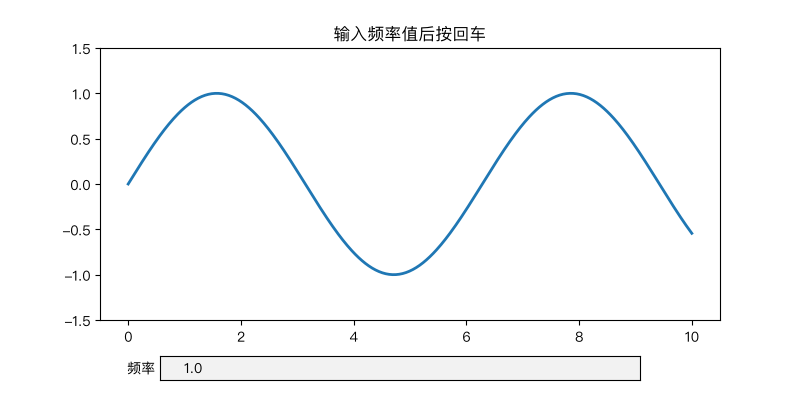

In [14]:
reset()
fig, ax = plt.subplots(figsize=(8, 4))
fig.subplots_adjust(bottom=0.2)

x = np.linspace(0, 10, 500)
line, = ax.plot(x, np.sin(x), lw=2)
ax.set_ylim(-1.5, 1.5)
ax.set_title('输入频率值后按回车')

text_ax = fig.add_axes((0.2, 0.05, 0.6, 0.06))
text_box = TextBox(text_ax, '频率', initial='1.0')

def submit(text):
    try:
        freq = float(text)
        line.set_ydata(np.sin(freq * x))
        fig.canvas.draw_idle()
    except ValueError:
        pass

text_box.on_submit(submit)